## Preprocessing of Home Loan Dataset

This notebook implements preprocessing steps based on the comprehensive EDA findings and recommendations. 

We'll follow the evidence-based approach from the EDA report to ensure our preprocessing aligns with the data patterns discovered.
Based on the EDA report, we will:

1. **Handle Skewed Variables** - Log-transform `ApplicantIncome`, `CoApllicantIncome`, `Loan Amount`, `credit History`
2. **Outlier Treatment** - IQR-capping for extreme - `ApplicantIncome`, `CoApllicantIncome`, `Loan Amount` 
3. **Feature Engineering** - Create `total income `, `loan_income ratio`, `income_term`
4. **Feature Selection** - Keep high-signal features, evaluate low-signal ones
5. **Scaling** - StandardScaler for distance-based models
6. **Target Handling** - Classification approach with stratified splits

**Key EDA Evidence to Implement**

- **High-signal features**: `Credit_History`
- **Low-signal features**: `CoapplicantIncome`, `LoanAmount`, `Loan_Amount_Term` `ApplicantIncome` (evaluate for removal)
- **Skewed variables**: `ApplicantIncome`, `CoApllicantIncome`, `Loan Amount` (log-transform)
- **Feature engineering**: Create `total_inocme` and `loan_income ratio`, `income_term`

In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import scipy as stat
import joblib
warnings.filterwarnings('ignore')

In [159]:
# Preprocessing libraries
from sklearn.preprocessing import StandardScaler, RobustScaler, StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix

In [160]:
# Statistical libraries
from scipy import stats
from scipy.stats import zscore, skew

# Set style for better visualizations
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("Libraries imported successfully!")

Libraries imported successfully!


In [161]:
df = pd.read_csv("EDA_homeloan_dataset.csv")
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [162]:
# create a copy for preprocessing

df_processed = df.copy()

In [163]:


# # Drop the 'Loan_ID' column from df_processed
df_processed = df_processed.drop(columns="Loan_ID")

# Display the first few rows
df_processed.head()


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
1,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
2,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
3,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
4,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


#### **2. EDA-Based Data Quality Assessment**

In [164]:
# 1. Check for missing values (EDA showed no missing values)
print("\n1. Missing Values:")
missing_values = df_processed.isnull().sum()
if missing_values.sum() > 0:
    print(missing_values[missing_values > 0])
else:
    print("No missing values found (as expected from EDA)")

# 2. Check for duplicates
print("\n2. Duplicate Rows:")
duplicates = df_processed.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print(f"Percentage of duplicates: {(duplicates/len(df_processed))*100:.2f}%")

# 3. Check skewness for variables identified in EDA as right-skewed
print("\n3. Skewness Analysis (EDA identified right-skewed variables):")
skewed_vars = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount']
for var in skewed_vars:
    if var in df_processed.columns:
        skewness = skew(df_processed[var])
        print(f"{var}: skewness = {skewness:.3f} ({'right-skewed' if skewness > 0.5 else 'approximately normal'})")

# 4. Check correlation with target (EDA evidence)
print("\n4. Correlation with Quality (EDA Evidence):")
# correlations = df_processed.corr()['Loan_Status'].sort_values(key=abs, ascending=False)
correlations = df_processed.select_dtypes(include=['number']).corr()['Loan_Status'].sort_values(key=abs, ascending=False)

print("High-signal features (|correlation| > 0.2):")
high_signal = correlations[abs(correlations) > 0.2].drop('Loan_Status')
for feature, corr in high_signal.items():
    print(f"  {feature}: {corr:.3f}")

print("\nLow-signal features (|correlation| < 0.1):")
low_signal = correlations[abs(correlations) < 0.1]
for feature, corr in low_signal.items():

    print(f"  {feature}: {corr:.3f}")


1. Missing Values:
No missing values found (as expected from EDA)

2. Duplicate Rows:
Number of duplicate rows: 0

3. Skewness Analysis (EDA identified right-skewed variables):
ApplicantIncome: skewness = 6.558 (right-skewed)
CoapplicantIncome: skewness = 7.411 (right-skewed)
LoanAmount: skewness = 2.671 (right-skewed)

4. Correlation with Quality (EDA Evidence):
High-signal features (|correlation| > 0.2):
  Credit_History: 0.430

Low-signal features (|correlation| < 0.1):
  CoapplicantIncome: -0.065
  LoanAmount: -0.037
  Loan_Amount_Term: -0.031
  ApplicantIncome: -0.005


#### **4. Outlier Treatment (EDA Recommendation)**

ased on EDA findings, handle outliers using IQR-capping method

In [165]:
# Let's create a function for IQR clipping

def IQR_Clipping(column):
    Q1 = df_processed[column].quantile(0.25)
    Q3 = df_processed[column].quantile(0.75)
    IQR = Q3 -Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR 

    # To get the number of capped outliers
    outliers_count = ((df[column]<lower) | (df_processed[column]>upper)).sum()
    if outliers_count > 0:
        df_processed[column] = np.where(df_processed[column]<lower, lower, np.where(df_processed[column]>upper, upper,df_processed[column]))
    print(f"\nTotal outlier capped for {column}: {outliers_count}")

In [166]:
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    IQR_Clipping(col)


Total outlier capped for ApplicantIncome: 49

Total outlier capped for CoapplicantIncome: 18

Total outlier capped for LoanAmount: 39


<!-- #### **3. Log-Transform Skewed Variables (EDA Recommendation)** -->

# Handling Skewed Data

We will Log_transform skewed data whic are applicantIncome, coapplicationIncome and LoanAmount

In [167]:
def Log_transform(column):
    """This function transforms skewed data"""
    print("*" * 30)
    print("Transforming...")
    np.log(df_processed[column])
    print(f"\nTransforming of {column} done succesfully")

    print("*" * 30)
    print("\nchecking of data is still skewed")
    plt.figure(figsize=(8,6))
    sns.histplot(data=df_processed[column], kde=True, bins=30)
    plt.title(f"Visual Graph to {column} to check skewness")


******************************
Transforming...

Transforming of ApplicantIncome done succesfully
******************************

checking of data is still skewed
******************************
Transforming...

Transforming of CoapplicantIncome done succesfully
******************************

checking of data is still skewed
******************************
Transforming...

Transforming of LoanAmount done succesfully
******************************

checking of data is still skewed


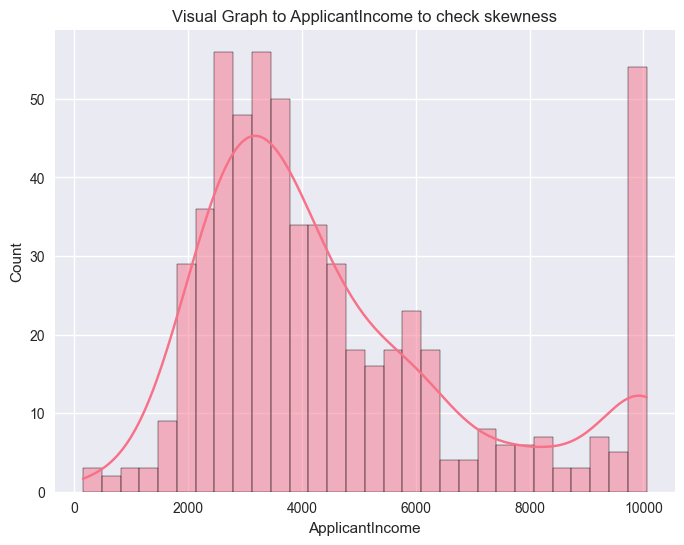

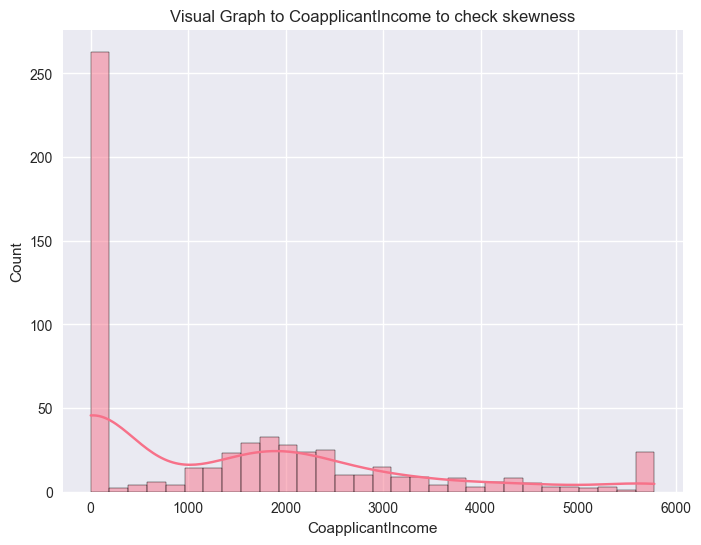

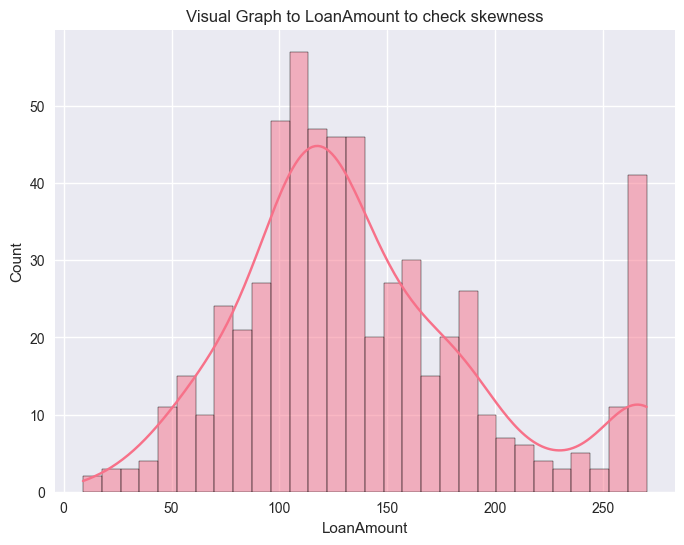

In [168]:
for col in ["ApplicantIncome", "CoapplicantIncome", "LoanAmount"]:
    Log_transform(col)

Based on our EDA findings, we will transforming the right-skewed variables

In [169]:
df_processed.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0
1,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,1
2,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1
3,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1
4,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1


#### **5. Feature Engineering**

Implement the specific feature engineering recommendations from the EDA report

In [170]:
# Creating Total Income
df_processed["Total_income"] = df_processed["ApplicantIncome"] + df_processed["CoapplicantIncome"]
print("Total amount of income is:")
print(df_processed["Total_income"].head(2))


# Creating Loan Income Ratio
df_processed["Income_ratio"] = np.divide(df_processed["Total_income"],df_processed["LoanAmount"])
print("Income ratio is:")
print(df_processed["Income_ratio"].head(2))

#Creating Income_per_term
df_processed["Income_per_term"] = np.divide(df_processed["Total_income"], df_processed["Loan_Amount_Term"])
print("Income_per_term:")
print(df_processed["Total_income"].head(2))

Total amount of income is:
0    6091.0
1    3000.0
Name: Total_income, dtype: float64
Income ratio is:
0    47.585938
1    45.454545
Name: Income_ratio, dtype: float64
Income_per_term:
0    6091.0
1    3000.0
Name: Total_income, dtype: float64


In [171]:
df_processed.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_income,Income_ratio,Income_per_term
0,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,0,6091.0,47.585938,16.919444
1,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,1,3000.0,45.454545,8.333333
2,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,1,4941.0,41.175000,13.725000
3,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,1,6000.0,42.553191,16.666667
4,Male,Yes,2,Graduate,Yes,5417.0,4196.0,267.0,360.0,1.0,Urban,1,9613.0,36.003745,26.702778


# Encoding Categorical Data

In [172]:
# selection of categorical Data
cat_cols = df_processed.select_dtypes(include="object").columns
cat_cols


# Loan_Status has label encoded from EDA  

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object')

FOr binary columns, label encoding will be done and one-hot encoding will be done for multi-categorical columns

In [173]:
# Label encodng 
le = LabelEncoder()

binary_col = ["Gender", "Married", "Education", "Self_Employed"]
for col in binary_col:
    df_processed[col] = le.fit_transform(df_processed[col])

# for OneHotEncoding for muti-categories
multi_col = ["Dependents","Property_Area"]

df_processed = pd.get_dummies(df_processed, columns=multi_col, drop_first=True)


df_processed = df_processed.drop(index=0)
df_processed.head(100)


,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_income,Income_ratio,Income_per_term,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
1,1,1,0,1,3000.000,0.0,66.0,360.0,1.0,1,3000.000,45.454545,8.333333,False,False,False,False,True
2,1,1,1,0,2583.000,2358.0,120.0,360.0,1.0,1,4941.000,41.175000,13.725000,False,False,False,False,True
3,1,0,0,0,6000.000,0.0,141.0,360.0,1.0,1,6000.000,42.553191,16.666667,False,False,False,False,True
4,1,1,0,1,5417.000,4196.0,267.0,360.0,1.0,1,9613.000,36.003745,26.702778,False,True,False,False,True
5,1,1,1,0,2333.000,1516.0,95.0,360.0,1.0,1,3849.000,40.515789,10.691667,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,1,0,0,0,4843.000,3806.0,151.0,360.0,1.0,1,8649.000,57.278146,24.025000,False,False,False,True,False
97,1,1,0,0,3816.000,754.0,160.0,360.0,1.0,1,4570.000,28.562500,12.694444,False,False,False,False,True
98,1,1,0,0,3052.000,1030.0,100.0,360.0,1.0,1,4082.000,40.820000,11.338889,True,False,False,False,True
99,1,1,0,0,10055.375,1126.0,225.0,360.0,1.0,1,11181.375,49.695000,31.059375,False,True,False,False,True


# Scaled numeric data

In [174]:
df_processed.head(1)

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_income,Income_ratio,Income_per_term,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
1,1,1,0,1,3000.0,0.0,66.0,360.0,1.0,1,3000.0,45.454545,8.333333,False,False,False,False,True


In [175]:
num_cols = df_processed[['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Total_income','Income_ratio', 'Income_per_term']]
num_cols

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Total_income,Income_ratio,Income_per_term
1,3000.0,0.0,66.0,360.0,1.0,3000.0,45.454545,8.333333
2,2583.0,2358.0,120.0,360.0,1.0,4941.0,41.175000,13.725000
3,6000.0,0.0,141.0,360.0,1.0,6000.0,42.553191,16.666667
4,5417.0,4196.0,267.0,360.0,1.0,9613.0,36.003745,26.702778
5,2333.0,1516.0,95.0,360.0,1.0,3849.0,40.515789,10.691667
...,...,...,...,...,...,...,...,...
587,2900.0,0.0,71.0,360.0,1.0,2900.0,40.845070,8.055556
588,4106.0,0.0,40.0,180.0,1.0,4106.0,102.650000,22.811111
589,8072.0,240.0,253.0,360.0,1.0,8312.0,32.853755,23.088889
590,7583.0,0.0,187.0,360.0,1.0,7583.0,40.550802,21.063889


In [176]:
# Let normalize numeric values 
scaler= StandardScaler()
# df_processed[num_cols.columns]= scaler.fit_transform(df_processed[num_cols])
# df_processed[num_cols.columns].std()

#  Fit and transform on the same DataFrame
df_processed[num_cols.columns] = scaler.fit_transform(df_processed[num_cols.columns])

# Check standard deviation (should be ~1 after scaling)
df_processed[num_cols.columns].std()

ApplicantIncome      1.000847
CoapplicantIncome    1.000847
LoanAmount           1.000847
Loan_Amount_Term     1.000847
Credit_History       1.000847
Total_income         1.000847
Income_ratio         1.000847
Income_per_term      1.000847
dtype: float64

In [177]:
# Let's see overall dataset
df_processed.head()

,Gender,Married,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Total_income,Income_ratio,Income_per_term,Dependents_1,Dependents_2,Dependents_3+,Property_Area_Semiurban,Property_Area_Urban
1,1,1,0,1,-0.653953,-0.876262,-1.245405,0.269827,0.541495,1,-1.155678,-0.079149,-0.422644,False,False,False,False,True
2,1,1,1,0,-0.824088,0.564021,-0.315308,0.269827,0.541495,1,-0.417169,-0.252010,-0.230717,False,False,False,False,True
3,1,0,0,0,0.570039,-0.876262,0.046397,0.269827,0.541495,1,-0.014243,-0.196341,-0.126002,False,False,False,False,True
4,1,1,0,1,0.332177,1.686683,2.216625,0.269827,0.541495,1,1.360426,-0.460889,0.231253,False,True,False,False,True
5,1,1,1,0,-0.926088,0.049721,-0.745908,0.269827,0.541495,1,-0.832652,-0.278637,-0.338694,False,False,False,False,True


## 6. Feature Selection

<Axes: >

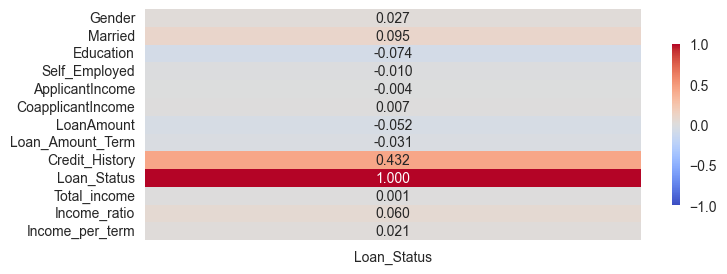

In [178]:
# sns.heatmap(df_processed.select_dtypes(include=["number"]).corr()[['Loan_Status']], annot=True, cmap="coolwarm").T
plt.figure(figsize=(8,3))
sns.heatmap(
    df_processed.select_dtypes(include=["number"]).corr()[['Loan_Status']],
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    cbar_kws={'orientation': 'vertical', 'shrink':0.7})
    

In [179]:
# let see the correlation again with encoded categorical labell included
corr = df_processed.corr()['Loan_Status'].abs().sort_values(ascending=False)
print(corr)

Loan_Status                1.000000
Credit_History             0.431894
Property_Area_Semiurban    0.124181
Married                    0.094584
Education                  0.074470
Dependents_2               0.067692
Income_ratio               0.059617
LoanAmount                 0.052172
Dependents_1               0.044239
Loan_Amount_Term           0.030630
Property_Area_Urban        0.030088
Gender                     0.026562
Income_per_term            0.020892
Dependents_3+              0.014348
Self_Employed              0.010146
CoapplicantIncome          0.006783
ApplicantIncome            0.003689
Total_income               0.000785
Name: Loan_Status, dtype: float64


In [181]:
# As evidence from EDA,  Credit_History is the only feature that gives 
# a moderate or useful signal for predicting Loan Status.

# using the whole data set let select feature with correlation of >0.05 with the target
# selected_features= corr[corr>0.05].index.tolist()
# selected_features.remove('Loan_Status') # Not to include the target
# no_selected_feature=len(selected_features)
# print("Total no of features(Encoding & Engineered):",len(df.columns) )
# print("No of features selected:",no_selected_feature )
# print("No of features to discard (low correlations):", len(df.columns) - no_selected_feature)
# print("selected_features are:", selected_features)
# df[selected_features].head(2)

In [ ]:

# for multicollinearity check
sns.heatmap(df_processed[selected_features].corr(), annot=True, cmap="coolwarm")
plt.show()

KeyError: "['Property_Area_Semiurban', 'Dependents_2', 'Income_ratio'] not in index"